# Ecommerce Sales Analysis

## Goal
Ecommerce 주문 데이터를 분석하여 상품별 매출과 판매량을 파악한다.

## Tech Stack
Python, Pandas, MySQL, Matplotlib

## Analysis Process
1. MySQL에서 데이터 불러오기
2. sales 컬럼 생성 (price × quantity)
3. 데이터 구조 확인
4. 상품별 매출 분석
5. 판매량 분석
6. 매출 트렌드 분석

In [43]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt

conn = pymysql.connect(
    host="localhost",
    user="web_user",
    password="1111",
    db="ecommerce",
    port=3306,
    charset="utf8"
)

In [44]:
df = pd.read_sql("select * from orders", conn)
df

C:\Users\USER\AppData\Local\Temp\ipykernel_540\435961634.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("select * from orders", conn)


,order_id,order_date,product_name,price,quantity
0,1.0,2026-01-05,Dog Shampoo,12000,1
1,2.0,2026-01-10,Dog Snack,5000,2
2,3.0,2026-02-01,Dog Leash,15000,1
3,4.0,2026-02-10,Dog Snack,5000,3
4,5.0,2026-03-03,Dog Toy,7000,1
...,...,...,...,...,...
400,NaN,2024-02-27,Dog Snack,5000,3
401,NaN,2024-01-13,Dog Snack,5000,5
402,NaN,2024-01-01,Dog Leash,15000,4
403,NaN,2024-02-04,Dog Snack,5000,5


In [61]:
df["sales"] = df["price"] * df["quantity"]
df

,order_id,order_date,product_name,price,quantity,sales
0,1.0,2026-01-05,Dog Shampoo,12000,1,12000
1,2.0,2026-01-10,Dog Snack,5000,2,10000
2,3.0,2026-02-01,Dog Leash,15000,1,15000
3,4.0,2026-02-10,Dog Snack,5000,3,15000
4,5.0,2026-03-03,Dog Toy,7000,1,7000
...,...,...,...,...,...,...
600,NaN,2024-01-08,Dog Snack,5000,4,20000
601,NaN,2024-01-10,Dog Shampoo,12000,1,12000
602,NaN,2024-02-01,Dog Food,20000,1,20000
603,NaN,2024-02-09,Dog Snack,5000,2,10000


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      5 non-null      float64
 1   order_date    405 non-null    object 
 2   product_name  405 non-null    str    
 3   price         405 non-null    int64  
 4   quantity      405 non-null    int64  
 5   sales         405 non-null    int64  
dtypes: float64(1), int64(3), object(1), str(1)
memory usage: 19.1+ KB


In [47]:
df.describe()

,order_id,price,quantity,sales
count,5.000000,405.000000,405.000000,405.000000
mean,3.000000,11303.703704,3.091358,34659.259259
std,1.581139,5487.980666,1.420866,24676.770743
min,1.000000,5000.000000,1.000000,5000.000000
25%,2.000000,7000.000000,2.000000,15000.000000
50%,3.000000,12000.000000,3.000000,28000.000000
75%,4.000000,15000.000000,4.000000,48000.000000
max,5.000000,20000.000000,5.000000,100000.000000


In [48]:
df["product_name"].value_counts()

product_name
Dog Toy        95
Dog Snack      91
Dog Food       76
Dog Leash      74
Dog Shampoo    69
Name: count, dtype: int64

In [49]:
df.groupby("product_name")["sales"].sum()

product_name
Dog Food       4680000
Dog Leash      3270000
Dog Shampoo    2532000
Dog Snack      1420000
Dog Toy        2135000
Name: sales, dtype: int64

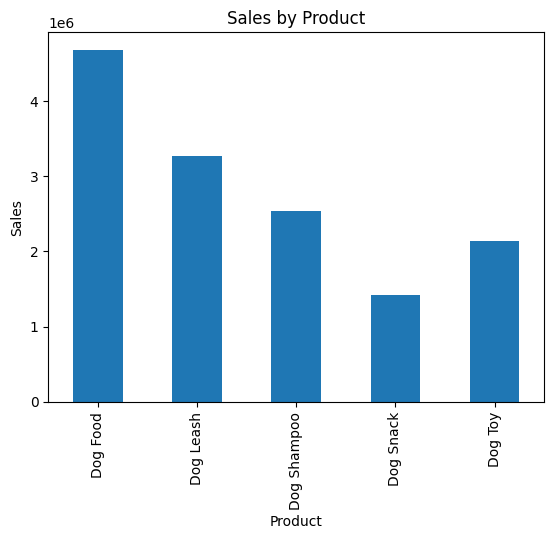

In [50]:
sales_by_product = df.groupby("product_name")["sales"].sum()

sales_by_product.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()

In [51]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [52]:
df.groupby("order_date")["sales"].sum()

order_date
2024-01-01    165000
2024-01-02    375000
2024-01-03     81000
2024-01-04    298000
2024-01-05    115000
               ...  
2026-01-05     12000
2026-01-10     10000
2026-02-01     15000
2026-02-10     15000
2026-03-03      7000
Name: sales, Length: 66, dtype: int64

In [53]:
df.groupby("product_name")[["quantity","sales"]].sum()

,quantity,sales
product_name,,
Dog Food,234,4680000
Dog Leash,218,3270000
Dog Shampoo,211,2532000
Dog Snack,284,1420000
Dog Toy,305,2135000


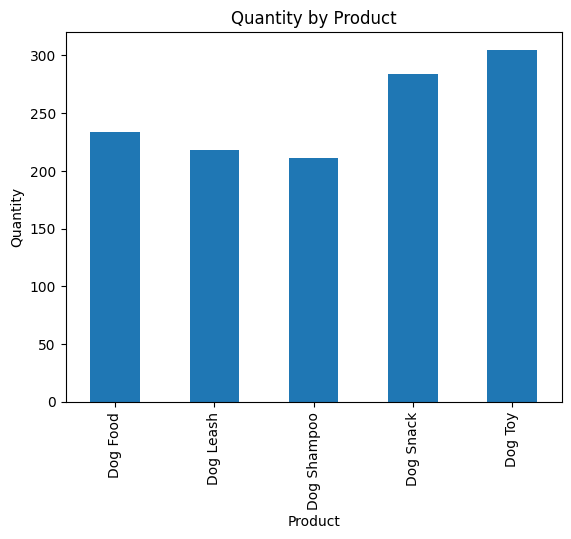

In [54]:
qty_by_product = df.groupby("product_name")["quantity"].sum()

qty_by_product.plot(kind="bar")

plt.title("Quantity by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")

plt.show()

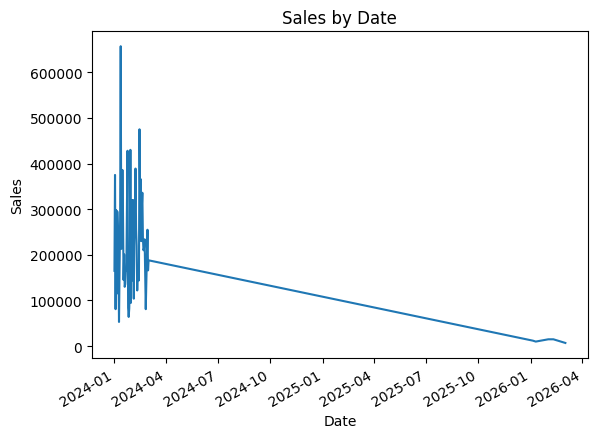

In [55]:
sales_by_date = df.groupby("order_date")["sales"].sum()

sales_by_date.plot(kind="line")

plt.title("Sales by Date")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [56]:
df.groupby("product_name")["quantity"].sum()

product_name
Dog Food       234
Dog Leash      218
Dog Shampoo    211
Dog Snack      284
Dog Toy        305
Name: quantity, dtype: int64

In [57]:
import random
from datetime import datetime, timedelta

products = [
    ("Dog Snack", 5000),
    ("Dog Toy", 7000),
    ("Dog Shampoo", 12000),
    ("Dog Leash", 15000),
    ("Dog Food", 20000)
]

start_date = datetime(2024, 1, 1)

data = []

for i in range(200):
    
    product = random.choice(products)
    
    order_date = start_date + timedelta(days=random.randint(0,60))
    
    quantity = random.randint(1,5)
    
    data.append((
        order_date.strftime("%Y-%m-%d"),
        product[0],
        product[1],
        quantity
    ))

print(len(data))

200


In [58]:
cursor = conn.cursor()

sql = """
INSERT INTO orders (order_date, product_name, price, quantity)
VALUES (%s,%s,%s,%s)
"""

cursor.executemany(sql, data)

conn.commit()

print("200 rows inserted!")

200 rows inserted!


In [59]:
df = pd.read_sql("select * from orders", conn)
df

C:\Users\USER\AppData\Local\Temp\ipykernel_540\435961634.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("select * from orders", conn)


,order_id,order_date,product_name,price,quantity
0,1.0,2026-01-05,Dog Shampoo,12000,1
1,2.0,2026-01-10,Dog Snack,5000,2
2,3.0,2026-02-01,Dog Leash,15000,1
3,4.0,2026-02-10,Dog Snack,5000,3
4,5.0,2026-03-03,Dog Toy,7000,1
...,...,...,...,...,...
600,NaN,2024-01-08,Dog Snack,5000,4
601,NaN,2024-01-10,Dog Shampoo,12000,1
602,NaN,2024-02-01,Dog Food,20000,1
603,NaN,2024-02-09,Dog Snack,5000,2


In [62]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(3)

top_products

product_name
Dog Food       7620000
Dog Leash      4665000
Dog Shampoo    3816000
Name: sales, dtype: int64

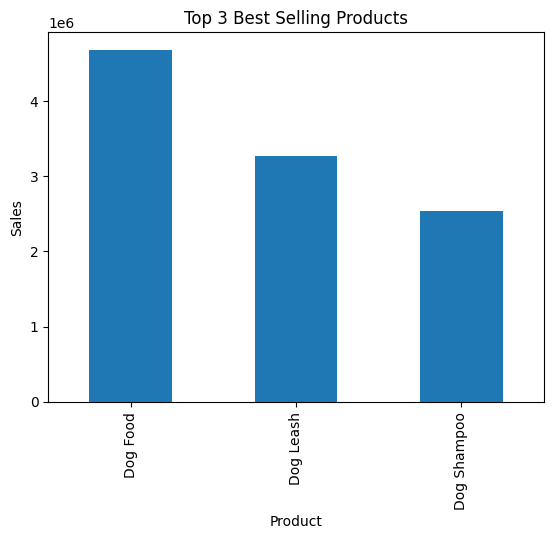

In [ ]:
top_products.plot(kind="bar")

plt.title("Top 3 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()

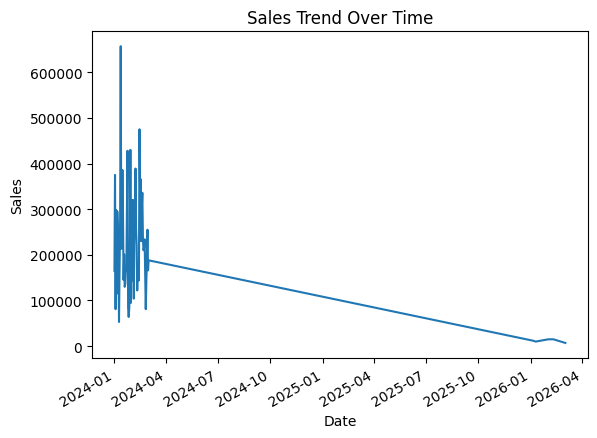

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])

sales_trend = df.groupby("order_date")["sales"].sum().sort_index()

sales_trend.plot(kind="line")

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()